✅ Data loaded successfully!
📊 Total Trades Loaded: 28
✅ Profit/Loss calculated for all trades.

📊  TRADING PERFORMANCE SUMMARY  📊
📈 Total Trades:          28
✅ Win Rate:              64.3%  (18 Wins / 6 Losses)
📉 Loss Rate:             21.4%
────────────────────────────────────────────────────────────
💰 Overall Profit (Net):  5.09%
📊 Avg Profit/Trade:      0.18%
────────────────────────────────────────────────────────────
🏆 Largest Win:           1.10%
💀 Largest Loss:          -1.00%
📈 Avg Win:               0.45%
📉 Avg Loss:              -0.52%
────────────────────────────────────────────────────────────
📊 Profit Factor:         2.64  ( > 1.0 is profitable)
📉 Max Drawdown:          -1.00%
────────────────────────────────────────────────────────────
📈 Long Win Rate:         62.5%  (16 Trades)
📉 Short Win Rate:        66.7%  (12 Trades)
────────────────────────────────────────────────────────────
😊 Emotional Breakdown (Pre-Trade Feelings):
   - Confident: 8 trades (28.6%)
   - Neutral: 

C:\Users\fatemeh\AppData\Local\Temp\ipykernel_16608\445424856.py:306: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\fatemeh\AppData\Local\Temp\ipykernel_16608\445424856.py:306: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\fatemeh\AppData\Local\Temp\ipykernel_16608\445424856.py:306: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\fatemeh\AppData\Local\Temp\ipykernel_16608\445424856.py:306: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\fatemeh\AppData\Local\Temp\ipykernel_16608\445424856.py:306: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\fatemeh\AppData\Local\Temp\ipykernel_16608\4454

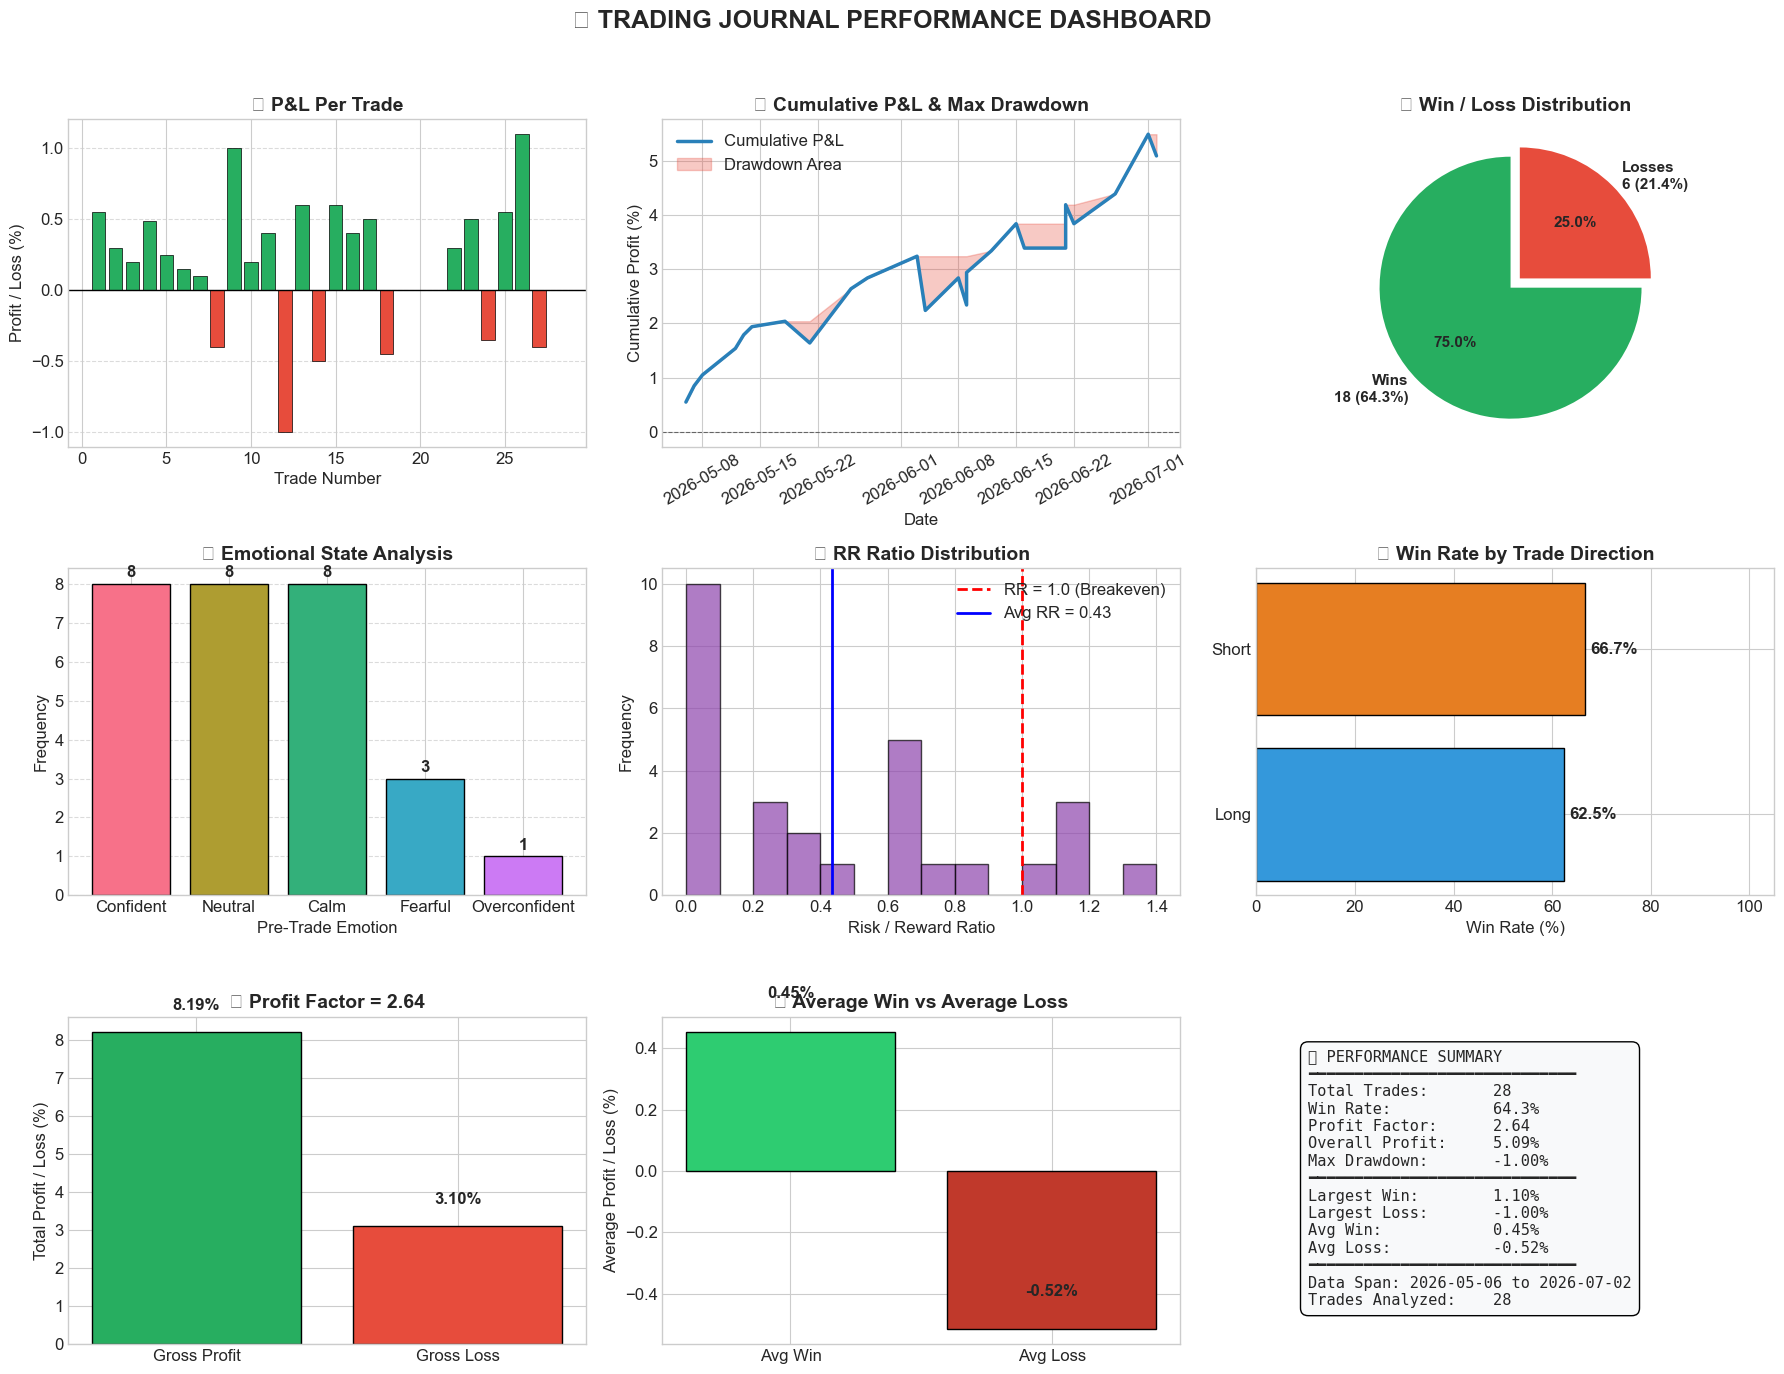


✅ Advanced Summary CSV saved as: 'trading_summary_advanced.csv'
✅ High-Resolution Dashboard saved as: 'trading_performance_dashboard.png'

🎯 Analysis Complete! You can now use these files for your portfolio/application.


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime

# ============================================
# 1. PROFESSIONAL STYLING (FIXED)
# ============================================

# Check which styles are available and use a safe one
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('ggplot')  # Fallback

sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ============================================
# 2. LOAD AND PREPARE DATA
# ============================================

# Load your JSON file
with open('trading_journal.json', 'r') as f:
    trades = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(trades)

# Convert date and sort chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Create a trade number column for plotting
df['trade_no'] = range(1, len(df) + 1)

print("✅ Data loaded successfully!")
print(f"📊 Total Trades Loaded: {len(df)}")

# ============================================
# 3. CALCULATE PROFIT/LOSS PER TRADE
# ============================================

# For winning trades: profit = reward_percent
# For losing trades: profit = -risk_percent (you lost your risk)
def calculate_profit(row):
    if row['win_loss'] == 'Win':
        return row['reward_percent']  # Positive profit
    elif row['win_loss'] == 'Loss':
        return -row['risk_percent']   # Negative profit (loss)
    else:
        return 0  # Breakeven

df['profit_percent'] = df.apply(calculate_profit, axis=1)

print(f"✅ Profit/Loss calculated for all trades.")

# ============================================
# 4. CALCULATE ALL REQUESTED METRICS
# ============================================

# --- Basic Counts ---
total_trades = len(df)
wins = df[df['win_loss'] == 'Win']
losses = df[df['win_loss'] == 'Loss']
breakeven = df[df['win_loss'] == 'Breakeven'] if 'Breakeven' in df['win_loss'].values else pd.DataFrame()

num_wins = len(wins)
num_losses = len(losses)

# --- Win Rate ---
win_rate = (num_wins / total_trades) * 100 if total_trades > 0 else 0
loss_rate = (num_losses / total_trades) * 100 if total_trades > 0 else 0

# --- Profit Metrics ---
total_profit_percent = df['profit_percent'].sum()
avg_profit_per_trade = df['profit_percent'].mean()

# Largest Win / Largest Loss
largest_win = wins['profit_percent'].max() if not wins.empty else 0
largest_loss = losses['profit_percent'].min() if not losses.empty else 0

# Average Win / Average Loss
avg_win = wins['profit_percent'].mean() if not wins.empty else 0
avg_loss = losses['profit_percent'].mean() if not losses.empty else 0

# --- Profit Factor (Gross Wins / Gross Losses) ---
gross_profit = wins['profit_percent'].sum() if not wins.empty else 0
gross_loss = abs(losses['profit_percent'].sum()) if not losses.empty else 0
profit_factor = gross_profit / gross_loss if gross_loss != 0 else float('inf')

# --- Max Drawdown (Peak-to-Trough decline in cumulative equity) ---
cumulative_profit = df['profit_percent'].cumsum()
running_max = cumulative_profit.cummax()
drawdown = cumulative_profit - running_max
max_drawdown_percent = drawdown.min()

# --- Emotional Numbers (if 'pre_emotion' column exists) ---
# Check for emotion column (your JSON has 'pre_emotion')
emotion_col = 'pre_emotion' if 'pre_emotion' in df.columns else None
if emotion_col:
    # Clean emotion strings (remove emojis if needed)
    df['emotion_clean'] = df[emotion_col].str.replace(r'[^\w\s]', '', regex=True).str.strip()
    emotion_counts = df['emotion_clean'].value_counts()
else:
    emotion_counts = pd.Series()

# --- Win Rate by Direction ---
if 'direction' in df.columns:
    long_trades = df[df['direction'] == 'Long']
    short_trades = df[df['direction'] == 'Short']
    win_rate_long = (len(long_trades[long_trades['win_loss'] == 'Win']) / len(long_trades) * 100) if len(long_trades) > 0 else 0
    win_rate_short = (len(short_trades[short_trades['win_loss'] == 'Win']) / len(short_trades) * 100) if len(short_trades) > 0 else 0
else:
    win_rate_long = 0
    win_rate_short = 0

# ============================================
# 5. PRINT PERFORMANCE SUMMARY
# ============================================

print("\n" + "="*60)
print("📊  TRADING PERFORMANCE SUMMARY  📊")
print("="*60)
print(f"📈 Total Trades:          {total_trades}")
print(f"✅ Win Rate:              {win_rate:.1f}%  ({num_wins} Wins / {num_losses} Losses)")
print(f"📉 Loss Rate:             {loss_rate:.1f}%")
print("─"*60)
print(f"💰 Overall Profit (Net):  {total_profit_percent:.2f}%")
print(f"📊 Avg Profit/Trade:      {avg_profit_per_trade:.2f}%")
print("─"*60)
print(f"🏆 Largest Win:           {largest_win:.2f}%")
print(f"💀 Largest Loss:          {largest_loss:.2f}%")
print(f"📈 Avg Win:               {avg_win:.2f}%")
print(f"📉 Avg Loss:              {avg_loss:.2f}%")
print("─"*60)
print(f"📊 Profit Factor:         {profit_factor:.2f}  ( > 1.0 is profitable)")
print(f"📉 Max Drawdown:          {max_drawdown_percent:.2f}%")
print("─"*60)
if 'direction' in df.columns:
    print(f"📈 Long Win Rate:         {win_rate_long:.1f}%  ({len(long_trades)} Trades)")
    print(f"📉 Short Win Rate:        {win_rate_short:.1f}%  ({len(short_trades)} Trades)")
print("─"*60)
if not emotion_counts.empty:
    print("😊 Emotional Breakdown (Pre-Trade Feelings):")
    for emotion, count in emotion_counts.items():
        print(f"   - {emotion}: {count} trades ({count/total_trades*100:.1f}%)")
else:
    print("😊 Emotional Data: Not available in JSON.")
print("="*60)

# ============================================
# 6. GENERATE PROFESSIONAL CHARTS
# ============================================

# Create figure with subplots
fig = plt.figure(figsize=(18, 14))
fig.suptitle('📈 TRADING JOURNAL PERFORMANCE DASHBOARD', fontsize=18, fontweight='bold', y=0.98)

# --- Chart 1: P&L Per Trade (Bar Chart) ---
ax1 = plt.subplot(3, 3, 1)
colors = ['#27AE60' if val > 0 else '#E74C3C' for val in df['profit_percent']]
bars = ax1.bar(df['trade_no'], df['profit_percent'], color=colors, edgecolor='black', linewidth=0.5)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Profit / Loss (%)')
ax1.set_title('💰 P&L Per Trade', fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Chart 2: Cumulative P&L with Max Drawdown Shading ---
ax2 = plt.subplot(3, 3, 2)
ax2.plot(df['date'], cumulative_profit, color='#2980B9', linewidth=2.5, label='Cumulative P&L')
ax2.fill_between(df['date'], cumulative_profit, running_max, color='#E74C3C', alpha=0.3, label='Drawdown Area')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Profit (%)')
ax2.set_title('📉 Cumulative P&L & Max Drawdown', fontweight='bold')
ax2.legend(loc='upper left')
ax2.tick_params(axis='x', rotation=30)

# --- Chart 3: Win/Loss Pie Chart ---
ax3 = plt.subplot(3, 3, 3)
labels = [f'Wins\n{num_wins} ({win_rate:.1f}%)', f'Losses\n{num_losses} ({loss_rate:.1f}%)']
sizes = [num_wins, num_losses]
colors_pie = ['#27AE60', '#E74C3C']
explode = (0.05, 0.05)
ax3.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', explode=explode, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax3.set_title('🎯 Win / Loss Distribution', fontweight='bold')

# --- Chart 4: Emotional Distribution ---
ax4 = plt.subplot(3, 3, 4)
if not emotion_counts.empty:
    emotion_colors = sns.color_palette("husl", len(emotion_counts))
    bars = ax4.bar(emotion_counts.index, emotion_counts.values, color=emotion_colors, edgecolor='black')
    ax4.set_xlabel('Pre-Trade Emotion')
    ax4.set_ylabel('Frequency')
    ax4.set_title('😊 Emotional State Analysis', fontweight='bold')
    ax4.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{int(height)}', ha='center', va='bottom', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No Emotional Data\nAvailable', ha='center', va='center', fontsize=14, transform=ax4.transAxes)
    ax4.set_title('😊 Emotional Data (Not Available)', fontweight='bold')
    ax4.set_xticks([])
    ax4.set_yticks([])

# --- Chart 5: RR Ratio Distribution ---
ax5 = plt.subplot(3, 3, 5)
if 'rr_ratio' in df.columns and len(df['rr_ratio'].dropna()) > 0:
    bins = np.linspace(df['rr_ratio'].min(), df['rr_ratio'].max(), 15)
    ax5.hist(df['rr_ratio'], bins=bins, color='#8E44AD', edgecolor='black', alpha=0.7)
    ax5.axvline(x=1, color='red', linestyle='--', linewidth=2, label='RR = 1.0 (Breakeven)')
    ax5.axvline(x=df['rr_ratio'].mean(), color='blue', linestyle='-', linewidth=2, label=f'Avg RR = {df["rr_ratio"].mean():.2f}')
    ax5.set_xlabel('Risk / Reward Ratio')
    ax5.set_ylabel('Frequency')
    ax5.set_title('📊 RR Ratio Distribution', fontweight='bold')
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'No RR Data Available', ha='center', va='center', fontsize=14, transform=ax5.transAxes)
    ax5.set_title('📊 RR Ratio (Not Available)', fontweight='bold')
    ax5.set_xticks([])
    ax5.set_yticks([])

# --- Chart 6: Win Rate by Direction (Horizontal Bar) ---
ax6 = plt.subplot(3, 3, 6)
if 'direction' in df.columns and len(df['direction'].dropna()) > 0:
    directions = ['Long', 'Short']
    win_rates_dir = [win_rate_long, win_rate_short]
    counts_dir = [len(long_trades), len(short_trades)]
    bars = ax6.barh(directions, win_rates_dir, color=['#3498DB', '#E67E22'], edgecolor='black')
    ax6.set_xlabel('Win Rate (%)')
    ax6.set_title('📊 Win Rate by Trade Direction', fontweight='bold')
    for bar in bars:
        width = bar.get_width()
        label = f'{width:.1f}%'
        ax6.text(width + 1, bar.get_y() + bar.get_height()/2, label, ha='left', va='center', fontweight='bold')
    ax6.set_xlim(0, 105)
else:
    ax6.text(0.5, 0.5, 'No Direction Data Available', ha='center', va='center', fontsize=14, transform=ax6.transAxes)
    ax6.set_title('📊 Direction (Not Available)', fontweight='bold')
    ax6.set_xticks([])
    ax6.set_yticks([])

# --- Chart 7: Profit Factor Breakdown (Wins vs Losses) ---
ax7 = plt.subplot(3, 3, 7)
if gross_profit > 0 or gross_loss > 0:
    bars = ax7.bar(['Gross Profit', 'Gross Loss'], [gross_profit, gross_loss], color=['#27AE60', '#E74C3C'], edgecolor='black')
    ax7.set_ylabel('Total Profit / Loss (%)')
    ax7.set_title(f'📊 Profit Factor = {profit_factor:.2f}', fontweight='bold')
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
else:
    ax7.text(0.5, 0.5, 'No Profit Data', ha='center', va='center', fontsize=14, transform=ax7.transAxes)
    ax7.set_title('📊 Profit Factor (No Data)', fontweight='bold')
    ax7.set_xticks([])
    ax7.set_yticks([])

# --- Chart 8: Average Win vs Average Loss ---
ax8 = plt.subplot(3, 3, 8)
if avg_win != 0 or avg_loss != 0:
    bars = ax8.bar(['Avg Win', 'Avg Loss'], [avg_win, avg_loss], color=['#2ECC71', '#C0392B'], edgecolor='black')
    ax8.set_ylabel('Average Profit / Loss (%)')
    ax8.set_title('📈 Average Win vs Average Loss', fontweight='bold')
    for bar in bars:
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
else:
    ax8.text(0.5, 0.5, 'No Data Available', ha='center', va='center', fontsize=14, transform=ax8.transAxes)
    ax8.set_title('📈 Avg Win/Loss (No Data)', fontweight='bold')
    ax8.set_xticks([])
    ax8.set_yticks([])

# --- Chart 9: Key Metric Card (Text Summary) ---
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = (
    f"📊 PERFORMANCE SUMMARY\n"
    f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    f"Total Trades:       {total_trades}\n"
    f"Win Rate:           {win_rate:.1f}%\n"
    f"Profit Factor:      {profit_factor:.2f}\n"
    f"Overall Profit:     {total_profit_percent:.2f}%\n"
    f"Max Drawdown:       {max_drawdown_percent:.2f}%\n"
    f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    f"Largest Win:        {largest_win:.2f}%\n"
    f"Largest Loss:       {largest_loss:.2f}%\n"
    f"Avg Win:            {avg_win:.2f}%\n"
    f"Avg Loss:           {avg_loss:.2f}%\n"
    f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
    f"Data Span: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}\n"
    f"Trades Analyzed:    {total_trades}"
)
ax9.text(0.1, 0.9, summary_text, transform=ax9.transAxes, fontsize=11, verticalalignment='top', family='monospace', bbox=dict(boxstyle="round,pad=0.5", facecolor='#F8F9FA', edgecolor='black'))

# --- Final Adjustments ---
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('trading_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 7. EXPORT SUMMARY TO CSV
# ============================================

summary_dict = {
    'Metric': [
        'Total Trades', 'Win Rate (%)', 'Loss Rate (%)',
        'Overall Profit (%)', 'Average Profit/Trade (%)',
        'Largest Win (%)', 'Largest Loss (%)',
        'Average Win (%)', 'Average Loss (%)',
        'Profit Factor', 'Max Drawdown (%)',
        'Win Rate Long (%)' if 'direction' in df.columns else 'Win Rate Long (N/A)',
        'Win Rate Short (%)' if 'direction' in df.columns else 'Win Rate Short (N/A)'
    ],
    'Value': [
        total_trades, f'{win_rate:.2f}', f'{loss_rate:.2f}',
        f'{total_profit_percent:.2f}', f'{avg_profit_per_trade:.2f}',
        f'{largest_win:.2f}', f'{largest_loss:.2f}',
        f'{avg_win:.2f}', f'{avg_loss:.2f}',
        f'{profit_factor:.2f}', f'{max_drawdown_percent:.2f}',
        f'{win_rate_long:.2f}' if 'direction' in df.columns else 'N/A',
        f'{win_rate_short:.2f}' if 'direction' in df.columns else 'N/A'
    ]
}
summary_df = pd.DataFrame(summary_dict)
summary_df.to_csv('trading_summary_advanced.csv', index=False)

print("\n✅ Advanced Summary CSV saved as: 'trading_summary_advanced.csv'")
print("✅ High-Resolution Dashboard saved as: 'trading_performance_dashboard.png'")
print("\n🎯 Analysis Complete! You can now use these files for your portfolio/application.")